
# Практическое задание №1

Проанализируйте данные о вакансиях на глобальном рынке труда в сфере ИИ в 2025 году.

[Источник](https://www.kaggle.com/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025)

В файле `ai_job_dataset.csv` содержаться следующие переменные:


- job_id: Unique identifier for each job posting
- job_title: Standardized job title	
- salary_usd:	Annual salary in USD	
- salary_currency:	Original salary currency	
- salary_local:	Salary in local currency	
- experience_level:	EN (Entry), MI (Mid), SE (Senior), EX (Executive)	
- employment_type:	FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance)	
- company_location:	Country where company is located	
- company_size:	S (Small <50), M (Medium 50-250), L (Large >250)	
- employee_residence:	Country where employee resides	
- remote_ratio:	0 (No remote), 50 (Hybrid), 100 (Fully remote)	
- required_skills:	Top 5 required skills (comma-separated)	
- education_required:	Minimum education requirement	
- years_experience:	Required years of experience	
- industry:	Industry sector of the company	
- posting_date:	Date when job was posted	
- application_deadline:	Application deadline	
- job_description_length:	Character count of job description	
- benefits_score:	Numerical score of benefits package (1-10)	

1. Опишите датасет (число наблюдений и переменных, пропущенных значений, типы данных, типы шкал переменных).

In [236]:

import pandas as pd

df = pd.read_csv("ai_job_dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  str    
 1   job_title               15000 non-null  str    
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  str    
 4   experience_level        15000 non-null  str    
 5   employment_type         15000 non-null  str    
 6   company_location        15000 non-null  str    
 7   company_size            15000 non-null  str    
 8   employee_residence      15000 non-null  str    
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  str    
 11  education_required      15000 non-null  str    
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  str    
 14  posting_date            15000 non-null  str    
 

В выводе выше указано, что в датасете 15000 наблюдений(строк) и 19 переменных(колонок). Согласно df.info() в датасете нет пропущенных значений, следовательно значения типа None, Nan отсутствуют. Типы данных: float64(1), int64(4), str(14) - однако, видно что posting_date и application_deadline изначально технически имеют тип str,но по смыслу это даты, сделаем маленькую предобработку: преобразуем их в тип datetime:

In [237]:
df["posting_date"] = pd.to_datetime(df["posting_date"])
df["application_deadline"] = pd.to_datetime(df["application_deadline"])

Теперь все столбцы точно правильных типов, проанализиурем типы шкал: 

Номинальные: job_title, salary_currency, employment_type, company_location, employee_residence, required_skills, industry, company_name, job_id

Порядковые: experience_level, company_size, education_required, benefits_score

Интервальные: posting_date, application_deadline

Отношений: salary_usd, remote_ratio, years_experience, job_description_length

2. Отобразите первые пять строк и последние три строки датасета.

Первые 5 строк:

In [238]:
df.head()


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


Последние 3 строки: 

In [239]:
df.tail(3)

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


3. Установите идентификатор вакансии (job_id) как индекс строк.

In [240]:
df = df.set_index("job_id")

4. Выведите список названий столбцов таблицы.

In [241]:
df.columns

Index(['job_title', 'salary_usd', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='str')

5. Выведите информацию о проценте непустых ячеек в каждом столбце.

In [242]:
df.notna().mean() * 100

job_title                 100.0
salary_usd                100.0
salary_currency           100.0
experience_level          100.0
employment_type           100.0
company_location          100.0
company_size              100.0
employee_residence        100.0
remote_ratio              100.0
required_skills           100.0
education_required        100.0
years_experience          100.0
industry                  100.0
posting_date              100.0
application_deadline      100.0
job_description_length    100.0
benefits_score            100.0
company_name              100.0
dtype: float64

6. Выведите описательные статистики по столбцам, содержащим количественные данные.

In [243]:
import numpy as np 
numeric_features = df.select_dtypes(include=[np.number])
numeric_features.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


7. Переименуйте столбец "industry" в "industry_comp".

In [244]:
df = df.rename(columns={"industry": "industry_comp"})

8. Выведите столбцы, характеризующие вознаграждение за работу.

In [245]:
df[["salary_usd", "salary_currency", "benefits_score"]]

,salary_usd,salary_currency,benefits_score
job_id,,,
AI00001,90376,USD,5.9
AI00002,61895,USD,5.2
AI00003,152626,USD,9.4
AI00004,80215,USD,8.6
AI00005,54624,EUR,6.6
...,...,...,...
AI14996,38604,USD,7.9
AI14997,57811,GBP,8.2
AI14998,189490,USD,7.4


9. Выведите название позиции для вакансии с идентификатором AI00056.

In [246]:
df.at['AI00056', 'job_title']

'AI Architect'

10. Отобразите данные о вакансиях, в которых заработная плата выше 200000 долларов США.

In [247]:
df[df["salary_usd"] > 200000]

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry_comp,posting_date,application_deadline,job_description_length,benefits_score,company_name
job_id,,,,,,,,,,,,,,,,,,
AI00049,AI Specialist,288815,USD,EX,PT,Switzerland,S,Switzerland,0,"Deep Learning, Git, Data Visualization, Linux,...",Bachelor,12,Manufacturing,2024-08-08,2024-09-23,1930,7.2,Cognitive Computing
AI00068,Machine Learning Engineer,316182,USD,EX,PT,Denmark,M,Canada,0,"Python, Scala, Statistics, Git",Associate,12,Finance,2025-02-09,2025-02-23,2452,7.0,Digital Transformation LLC
AI00077,AI Product Manager,213783,USD,EX,FT,Canada,S,Canada,100,"Kubernetes, Spark, Statistics, Scala",Bachelor,16,Energy,2024-09-19,2024-10-06,2383,9.2,Quantum Computing Inc
AI00080,AI Research Scientist,284486,USD,EX,CT,United States,M,United States,0,"PyTorch, Linux, SQL",Master,12,Consulting,2025-02-13,2025-03-10,2231,7.0,TechCorp Inc
AI00083,Machine Learning Researcher,207548,USD,EX,CT,Canada,M,Canada,0,"NLP, Azure, Spark, Data Visualization",PhD,10,Energy,2024-02-05,2024-03-11,2292,6.7,Cognitive Computing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AI14964,AI Architect,238571,USD,EX,FT,Singapore,S,Singapore,50,"Hadoop, Java, Deep Learning",PhD,11,Government,2024-03-09,2024-04-09,573,9.0,Cognitive Computing
AI14969,Robotics Engineer,233563,USD,EX,FT,Sweden,M,Sweden,100,"Linux, NLP, SQL, GCP, R",Master,18,Energy,2025-01-24,2025-02-27,2400,5.2,DataVision Ltd
AI14978,Research Scientist,325968,USD,EX,CT,Norway,M,Israel,100,"Python, Spark, MLOps, Computer Vision, Deep Le...",Associate,10,Technology,2024-07-17,2024-09-13,1514,9.8,Quantum Computing Inc


11. Создайте новый столбец, в котором размер заработной платы рассчитан в рублях по текущему курсу.

In [248]:
usd_to_rub = 84.7 #курс доллара к рублю на 22.09.26
df["salary_rubles"] = df["salary_usd"] * usd_to_rub


12. Создайте новый столбец is_local, который будет иметь значение True, если company_location == employee_residence, и False в противном случае.

In [249]:
df["is_local"] = df["company_location"] == df["employee_residence"]

13. Рассчитайте средние заработные платы для вакансий с различными требованиями к опыту кандидатов.

In [250]:
df.groupby("experience_level")["salary_usd"].mean()

experience_level
EN     63133.377084
EX    187723.647340
MI     87955.471833
SE    122187.657845
Name: salary_usd, dtype: float64

Средняя годовая зарплата последовательно увеличивается с уровнем опыта: EN — около 63 133 долларов, MI — 87 955, SE — 122 188, EX — 187 724. Средняя зарплата вакансий уровня EX почти втрое выше, чем уровня EN.

14. Рассчитайте минимальные заработные платы для различных должностей для компаний разного размера (в одной таблице). 

In [251]:
df.groupby(["job_title", "company_size"])["salary_usd"].min().unstack()

company_size,L,M,S
job_title,,,
AI Architect,41846,36338,33220
AI Consultant,42570,36071,33959
AI Product Manager,42239,36162,33770
AI Research Scientist,42869,36574,33092
AI Software Engineer,42835,36152,33013
AI Specialist,41740,36553,34174
Autonomous Systems Engineer,42185,36197,32790
Computer Vision Engineer,42189,36732,32519
Data Analyst,41634,36523,32542


Для каждой представленной должности минимальная зарплата выше в крупных компаниях, чем в средних, и выше в средних, чем в малых.

15. Рассчитайте медиану требуемого опыта работы в годах для вакансий в китайских компаниях с требованием уровня образования не ниже магистерского.

In [252]:
float(df[
    (df["company_location"] == "China") &
    (df["education_required"].isin(["Master", "PhD"]))
]["years_experience"].median())

5.0

Для вакансий в китайских компаниях с требованием образования Master или PhD медианный требуемый опыт составляет 5 лет.

16. Постройте гистограммы трех различных метрических переменных и опишите их. Столбики первой гистограммы должны быть красного цвета, второй - синего, третьей - зеленого.

array([[<Axes: title={'center': 'benefits_score'}>]], dtype=object)

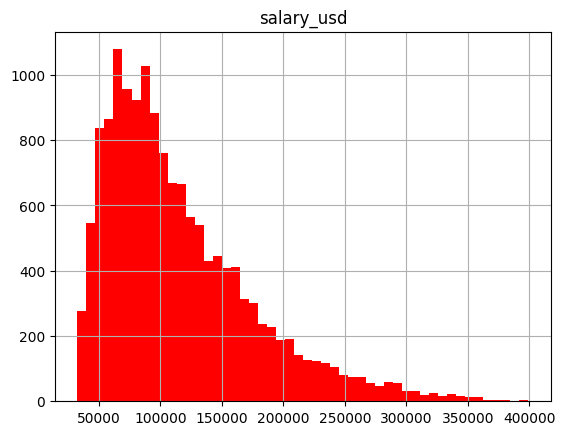

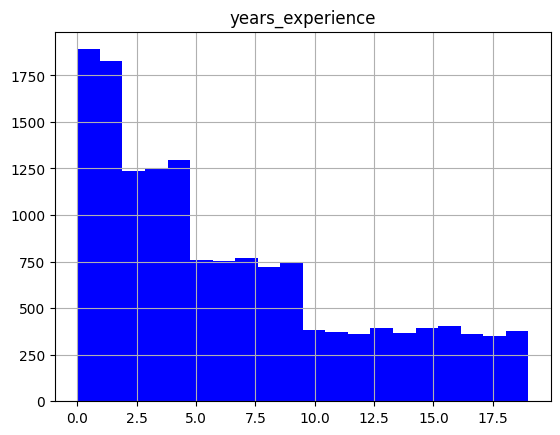

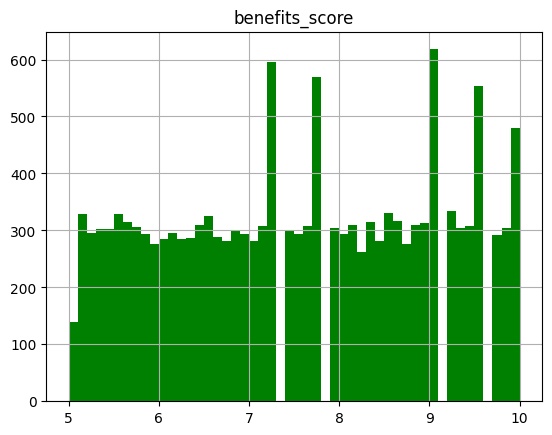

In [253]:
df.hist(column="salary_usd", color="red", bins = 50)
df.hist(column="years_experience", color="blue", bins = 20)
df.hist(column="benefits_score", color="green", bins = 50)

salary_usd:
Распределение заработной платы имеет выраженную правостороннюю асимметрию. Основная часть вакансий сосредоточена примерно в диапазоне 50–100 тыс. долларов, а по мере роста зарплаты количество вакансий уменьшается. Наблюдается длинный правый хвост вплоть до значений около 400 тыс. долларов, то есть вакансии с очень высокой зарплатой встречаются значительно реже.

years_experience:
Распределение требуемого опыта также имеет правостороннюю асимметрию. Наибольшее количество вакансий требует небольшой опыт работы - примерно 0–5 лет. С увеличением требуемого стажа число вакансий постепенно уменьшается. Вакансии с требованиями около 15–19 лет опыта встречаются существенно реже.

benefits_score:
Значения benefits_score находятся в диапазоне примерно от 5 до 10 баллов. В целом распределение выглядит довольно равномерным, без выраженной правой или левой асимметрии. При этом для некоторых отдельных значений наблюдаются более высокие частоты, поэтому на гистограмме присутствуют отдельные пики.

17. Постройте диаграмму, демонстрирующую взаимосвязь между размером компании и заработной платой. Добавьте название диаграмме и подписи осям. Обоснуйте выбор диаграммы и прокомментируйте тенденции и взаимосвязи, которые на ней отображены.

<Axes: title={'center': 'Медианная заработная плата в зависимости от размера компании'}, xlabel='Размер компании', ylabel='Медианная заработная плата, USD'>

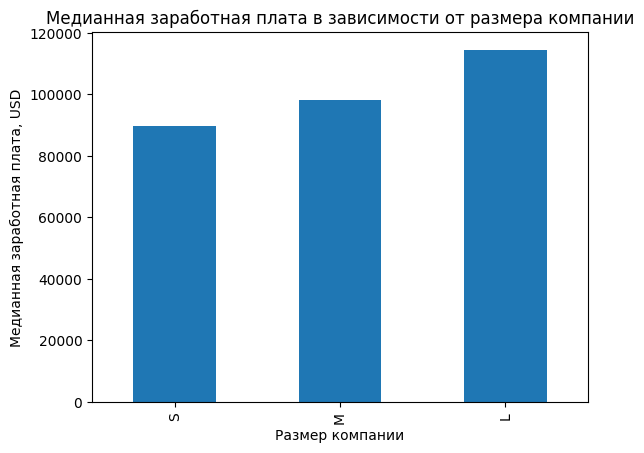

In [254]:
df.groupby("company_size")["salary_usd"].median().reindex(["S", "M", "L"]).plot(
    kind="bar",
    title="Медианная заработная плата в зависимости от размера компании",
    xlabel="Размер компании",
    ylabel="Медианная заработная плата, USD"
)

Для отображения взаимосвязи между размером компании и заработной платой была выбрана столбчатая диаграмма. Размер компании является категориальной порядковой переменной, поэтому столбчатая диаграмма позволяет наглядно сравнить медианные значения заработной платы между категориями S, M и L. В качестве характеристики заработной платы использована медиана, поскольку распределение зарплат имеет выраженную правостороннюю асимметрию и медиана менее чувствительна к экстремально высоким значениям. На диаграмме наблюдается положительная тенденция: с увеличением размера компании медианная заработная плата возрастает.

18. Постройте ящичковую диаграмму заработной платы. Наблюдаются ли выбросы?

<Axes: >

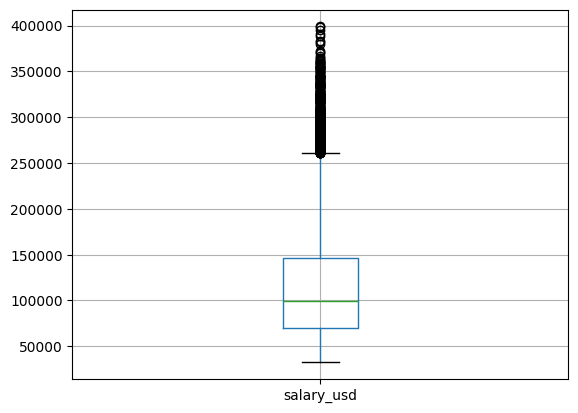

In [255]:
df.boxplot(column="salary_usd")

Наблюдаются выбросы в области высоких заработных плат.

19. Определите топ-5 стран по количеству вакансий. Визуализируйте это с помощью столбчатой диаграммы.

<Axes: title={'center': 'Топ-5 стран по количеству вакансий'}, xlabel='Страна', ylabel='Количество вакансий'>

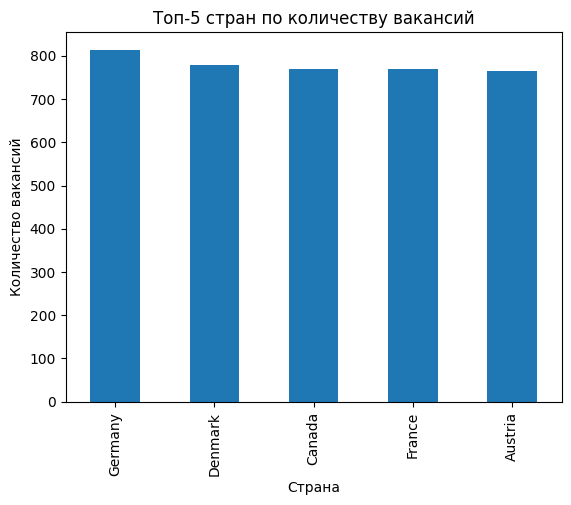

In [256]:
df["company_location"].value_counts().head(5).plot(
    kind="bar",
    title="Топ-5 стран по количеству вакансий",
    xlabel="Страна",
    ylabel="Количество вакансий"
)

По количеству вакансий лидирует Германия — 814. Далее следуют Дания — 778, Франция и Канада — по 769, Австрия — 765. Различия между странами первой пятёрки относительно небольшие.

20. Как связаны формат работы и зарплата? Кто получает больше — офисные, гибридные или полностью удалённые работники? Отличаются ли эти тенденции по странам?

<Axes: title={'center': 'Медианная зарплата в зависимости от формата работы'}, xlabel='Формат работы', ylabel='Медианная зарплата, USD'>

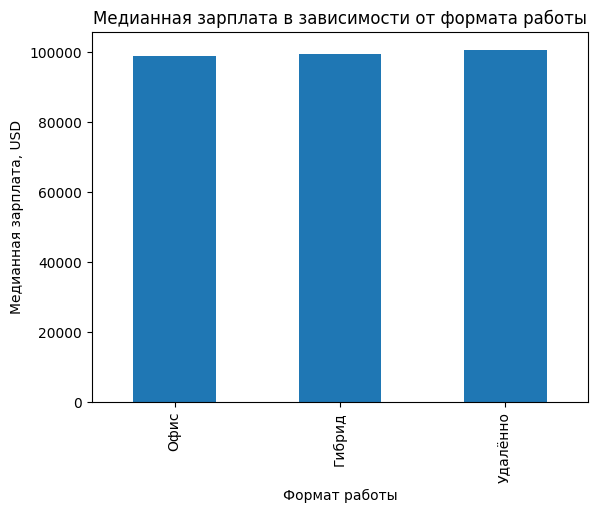

In [257]:
df.groupby("remote_ratio")["salary_usd"].median().rename(index={0: "Офис",50: "Гибрид",100: "Удалённо"}).plot(
    kind="bar",
    title="Медианная зарплата в зависимости от формата работы",
    xlabel="Формат работы",
    ylabel="Медианная зарплата, USD"
)

Медианная заработная плата различается в зависимости от формата работы незначительно. Наибольшее медианное значение наблюдается у полностью удалённых вакансий.

In [258]:
df.groupby(["company_location", "remote_ratio"])["salary_usd"].median().unstack().rename(columns={0: "Офис",50: "Гибрид",100: "Удалённо"})


remote_ratio,Офис,Гибрид,Удалённо
company_location,,,
Australia,99952.5,114982.0,98396.5
Austria,73465.0,70505.0,78418.5
Canada,101106.0,98899.5,101052.0
China,73867.0,76865.0,78895.0
Denmark,153378.0,153629.0,139154.0
Finland,73676.0,81262.5,85401.0
France,103062.0,101929.0,100087.0
Germany,103917.5,105368.0,118900.0
India,77756.5,72358.0,77209.0


Тенденции по странам отличаются. Общая тенденция, которую мы увидели раньше — у удалённых вакансий медианная зарплата немного выше — не сохраняется во всех странах.

21. Насколько часто место расположения компании и место проживания сотрудника не совпадают? Влияет ли это на зарплату?

In [259]:
df["is_local"].value_counts(normalize=True) * 100

is_local
True     71.626667
False    28.373333
Name: proportion, dtype: float64

Отсюда видно, что в 28 процентах случаев расположение компании и место проживания сотрудника не совпадают. 

In [260]:
df.groupby("is_local")["salary_usd"].median()

is_local
False    100146.5
True      99516.0
Name: salary_usd, dtype: float64

Медианная зарплата людей, у которых расположение компании и место проживания не совпадают, незначительно больше, поэтому выраженной связи между совпадением локаций и заработной платой не наблюдается.

22. Охарактеризуйте распределение требуемого опыта работы для каждой профессии.

In [261]:
df.groupby("job_title")["years_experience"].describe()

,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
AI Architect,771.0,6.498054,5.422027,0.0,2.0,5.0,10.0,19.0
AI Consultant,704.0,6.099432,5.406260,0.0,2.0,4.0,9.0,19.0
AI Product Manager,743.0,6.086137,5.462256,0.0,1.0,4.0,9.5,19.0
AI Research Scientist,756.0,6.403439,5.689534,0.0,2.0,5.0,10.0,19.0
AI Software Engineer,784.0,6.227041,5.724584,0.0,1.0,4.0,10.0,19.0
AI Specialist,728.0,6.561813,5.588505,0.0,2.0,5.0,10.0,19.0
Autonomous Systems Engineer,777.0,6.088803,5.456113,0.0,2.0,4.0,9.0,19.0
Computer Vision Engineer,724.0,5.954420,5.325569,0.0,2.0,4.0,9.0,19.0
Data Analyst,759.0,5.956522,5.404919,0.0,1.0,4.0,9.0,19.0


<Axes: title={'center': 'years_experience'}, xlabel='job_title'>

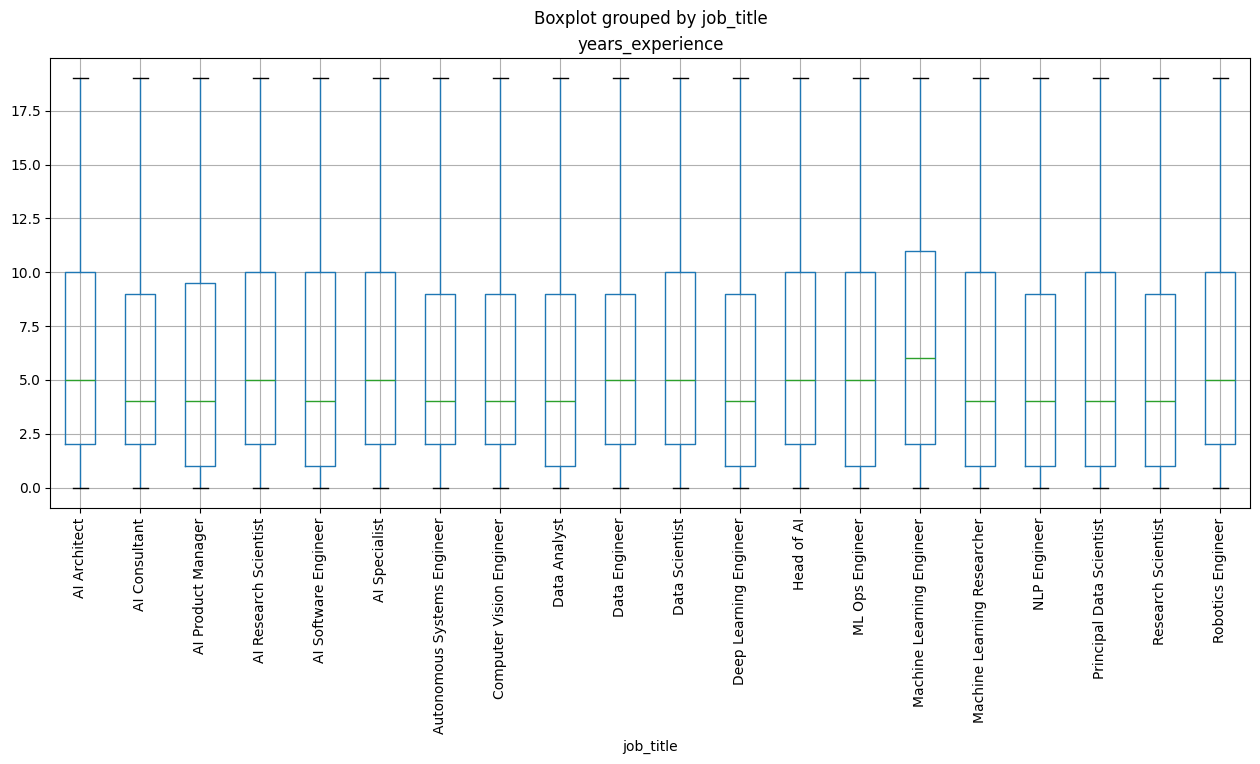

In [262]:
df.boxplot(
    column="years_experience",
    by="job_title",
    figsize=(15, 6),
    rot=90
)

Распределение требуемого опыта работы по профессиям в целом схоже. Средний требуемый опыт составляет приблизительно от 6 до 7 лет, а медианный — преимущественно от 4 до 5 лет. Наибольший средний и медианный опыт наблюдается для вакансий Machine Learning Engineer — около 6,72 и 6 лет соответственно. Для большинства профессий среднее значение превышает медиану, что свидетельствует о правосторонней асимметрии распределения. Стандартное отклонение составляет около 5–6 лет, что говорит о значительном разбросе требований к опыту. Во всех профессиях встречаются вакансии как без требований к опыту, так и с требованием до 19 лет стажа. В целом различия между профессиями выражены не очень сильно.

23. Есть ли взаимосвязь между числом символов в описании вакансии и зарплатой?

<Axes: title={'center': 'Связь длины описания вакансии и заработной платы'}, xlabel='Количество символов в описании', ylabel='Заработная плата, USD'>

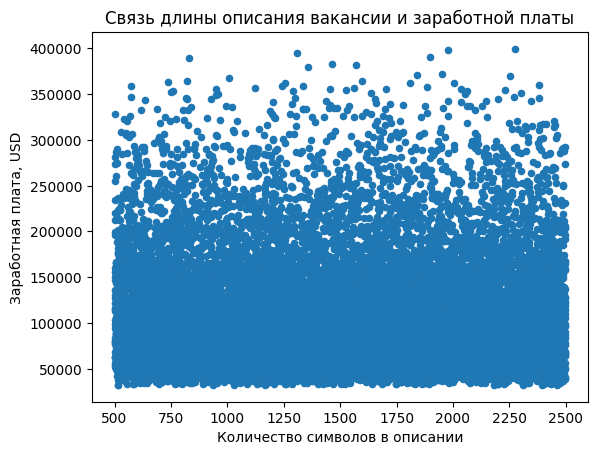

In [263]:
df.plot(
    kind="scatter",
    x="job_description_length",
    y="salary_usd",
    title="Связь длины описания вакансии и заработной платы",
    xlabel="Количество символов в описании",
    ylabel="Заработная плата, USD"
)

По диаграмме рассеяния явной зависимости между длиной описания вакансии и зарплатой не видно.

24. Визуализируйте распределение вакансий по месяцам (posting_date). Какие тенденции наблюдаются?

<Axes: title={'center': 'Количество опубликованных вакансий по месяцам'}, xlabel='Месяц', ylabel='Количество вакансий'>

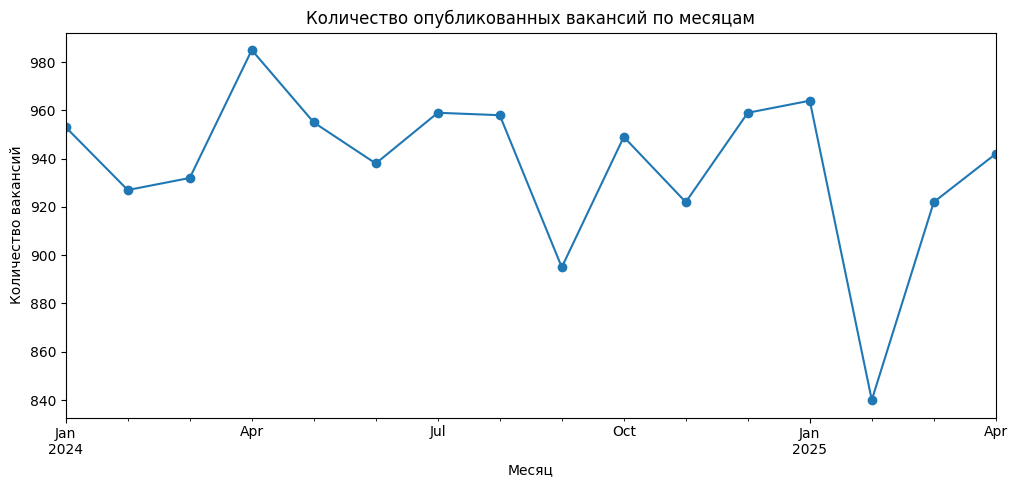

In [264]:
vacancies_by_month = df.groupby(
    df["posting_date"].dt.to_period("M")
).size()

vacancies_by_month.plot(
    kind="line",
    marker="o",
    figsize=(12, 5),
    title="Количество опубликованных вакансий по месяцам",
    xlabel="Месяц",
    ylabel="Количество вакансий"
)

На основании рассматриваемого периода нельзя уверенно говорить о каких то тенденциях, поскольку данные охватывают лишь один полный год и несколько месяцев следующего года. Явного долгосрочного тренда роста или снижения не наблюдается. В большинстве месяцев количество опубликованных вакансий колеблется примерно в диапазоне 900–980. В феврале наблюдается спад до примерно 850 вакансий. 

25. Рассчитайте временную разницу между posting_date и application_deadline. Влияет ли она на зарплату?

<Axes: title={'center': 'Связь срока подачи заявки и заработной платы'}, xlabel='Количество дней до дедлайна', ylabel='Заработная плата, USD'>

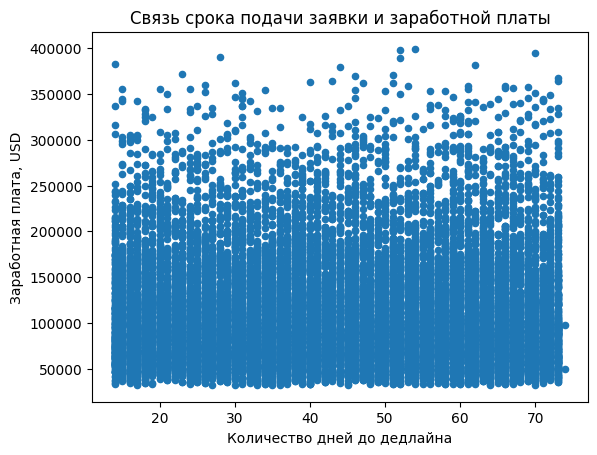

In [265]:
df["application_period"] = (df["application_deadline"] - df["posting_date"]).dt.days

df.plot(
    kind="scatter",
    x="application_period",
    y="salary_usd",
    title="Связь срока подачи заявки и заработной платы",
    xlabel="Количество дней до дедлайна",
    ylabel="Заработная плата, USD"
)

Диаграмма рассеяния не показывает выраженной зависимости между длительностью периода подачи заявки и заработной платой

26. Как сочетаются education_required и years_experience? Требуется ли больше лет опыта при меньшем образовании?

<Axes: title={'center': 'Требуемый опыт в зависимости от уровня образования'}, xlabel='Требуемое образование', ylabel='Медианный опыт, лет'>

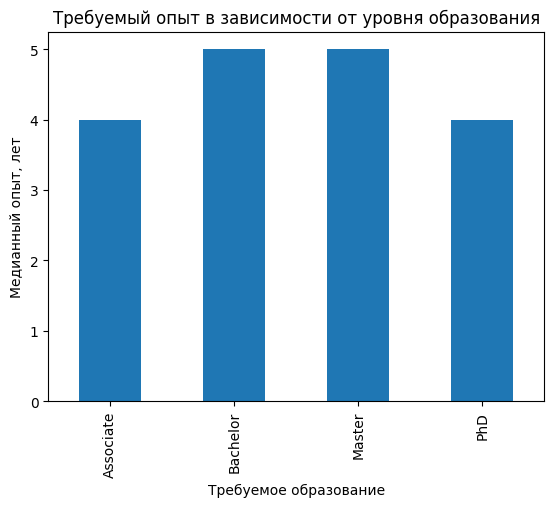

In [266]:
df.groupby("education_required")["years_experience"].median().reindex(["Associate", "Bachelor", "Master", "PhD"]).plot(
    kind="bar",
    title="Требуемый опыт в зависимости от уровня образования",
    xlabel="Требуемое образование",
    ylabel="Медианный опыт, лет"
)



Предположение о том, что при более низком уровне образования требуется больше лет опыта, по данным выборки не подтверждается. Явной зависимости между уровнем требуемого образования и требуемым опытом работы не наблюдается.

27. Опишите профиль вакансий с самыми высокими заработными платами (самостоятельно установите критерии отнесения зарплат к высоким). Что наиболее востребовано на таких вакансиях? Отличаются ли требования к кандидатам с самыми высокими зарплатами по странам?

In [267]:
# Порог — верхние 10% зарплат
high_salary= df["salary_usd"].quantile(0.9)

high_salary_jobs = df[df["salary_usd"] >= high_salary]

# Самые востребованные профессии
high_salary_jobs["job_title"].value_counts().head(10)


job_title
Head of AI                     94
Machine Learning Engineer      93
Principal Data Scientist       86
Robotics Engineer              85
AI Research Scientist          84
Research Scientist             84
Machine Learning Researcher    83
AI Specialist                  81
AI Architect                   78
AI Software Engineer           75
Name: count, dtype: int64

In [268]:
# Уровни опыта
high_salary_jobs["experience_level"].value_counts()

experience_level
EX    1390
SE     110
Name: count, dtype: int64

In [269]:
# Образование
high_salary_jobs["education_required"].value_counts()

education_required
Bachelor     396
Master       391
Associate    364
PhD          349
Name: count, dtype: int64

In [270]:
# Опыт работы
high_salary_jobs["years_experience"].describe()

count    1500.000000
mean       13.876667
std         3.421880
min         5.000000
25%        11.000000
50%        14.000000
75%        17.000000
max        19.000000
Name: years_experience, dtype: float64

In [271]:
# Самые востребованные навыки
skills = high_salary_jobs["required_skills"].str.split(", ").explode()
skills.value_counts().head(10)

required_skills
Python        441
SQL           323
Scala         301
TensorFlow    294
PyTorch       280
Kubernetes    273
Linux         269
Git           263
Java          262
Hadoop        254
Name: count, dtype: int64

In [272]:
# Различия в опыте по странам
high_salary_jobs.groupby("company_location")["years_experience"].median()

company_location
Australia         14.0
Austria           15.0
Canada            14.0
China             14.0
Denmark           13.0
Finland           19.0
France            14.0
Germany           14.0
India             16.5
Ireland           14.0
Israel            14.5
Japan             13.0
Netherlands       15.0
Norway            14.0
Singapore         14.0
South Korea       15.0
Sweden            14.0
Switzerland       13.0
United Kingdom    14.0
United States     15.0
Name: years_experience, dtype: float64

In [273]:
# Различия в образовании по странам
high_salary_jobs.groupby(["company_location", "education_required"]).size().unstack(fill_value=0)

education_required,Associate,Bachelor,Master,PhD
company_location,,,,
Australia,20,19,18,20
Austria,2,2,1,2
Canada,16,16,16,18
China,1,2,1,3
Denmark,51,61,68,46
Finland,2,3,0,2
France,9,20,16,18
Germany,17,27,18,22
India,1,1,0,0


В качестве высокооплачиваемых были выбраны вакансии, входящие в верхние 10% распределения заработных плат. Сразу можно заметить, что для таких вакансий очень серьезные требования к опыту работы: около 92,7% вакансий относятся к уровню EX, а медианный требуемый стаж составляет 14 лет. При этом требования к образованию распределены достаточно равномерно между Associate, Bachelor, Master и PhD, поэтому явного требования определённого уровня образования не наблюдается. Самые высокооплачиваемые профессии — Head of AI и Machine Learning Engineer. Наиболее востребованным навыком является Python, далее следуют SQL, Scala, TensorFlow и PyTorch. 

Требования к кандидатам по странам: медианный опыт в большинстве стран составляет 13–15 лет. А вот требования к образованию заметно варьируется в разных странах. Следовательно, для высокооплачиваемых вакансий наиболее выраженным требованием является высокий уровень профессионального опыта, тогда как требования к образованию сильнее зависят от страны.

**Комментарии к заданию и принципам его оценивания:**

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов описательного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях инструментов.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.
 - При использовании инструментов искусственного интеллекта необходимо отметить это в работе в соответствии с правилами НИУ ВШЭ.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 21:00 4 октября.